# Atividade 3
**Autores:** Leonardo Ono, Lucca Costa, Kevin Lima

In [7]:
# Importar bibliotecas necessárias
from bcb import sgs
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime
import plotly.io as pio
import matplotlib.pyplot as plt
from fredapi import Fred
from scipy import stats
import numpy as np
import seaborn as sns
import sidrapy
from scipy.stats import gaussian_kde

# Juros
**Estabelecendo as bases**

**Selic**

In [8]:
# Estabelecendo a base de dados para a taxa Selic
# Anual (432 é o código da série histórica da taxa Selic anual) (11 é o código da série histórica da taxa Selic diaria)
selic1 = sgs.get({'selic': 432}, start="2000-01-01", end="2009-12-31")
selic1 = selic1.rename(columns={'selic': 'taxa_selic'})

In [9]:
selic2 = sgs.get({'selic': 432}, start="2010-01-01", end="2019-12-31")
selic2 = selic2.rename(columns={'selic': 'taxa_selic'})

In [10]:
selic3 = sgs.get({'selic': 432}, start="2020-01-01", end=datetime.now().strftime('%Y-%m-%d'))
selic3 = selic3.rename(columns={'selic': 'taxa_selic'})

In [11]:
selic = pd.concat([selic1, selic2, selic3])

selic

,taxa_selic
Date,
2000-01-01,19.0
2000-01-02,19.0
2000-01-03,19.0
2000-01-04,19.0
2000-01-05,19.0
...,...
2026-05-17,14.5
2026-05-18,14.5
2026-05-19,14.5


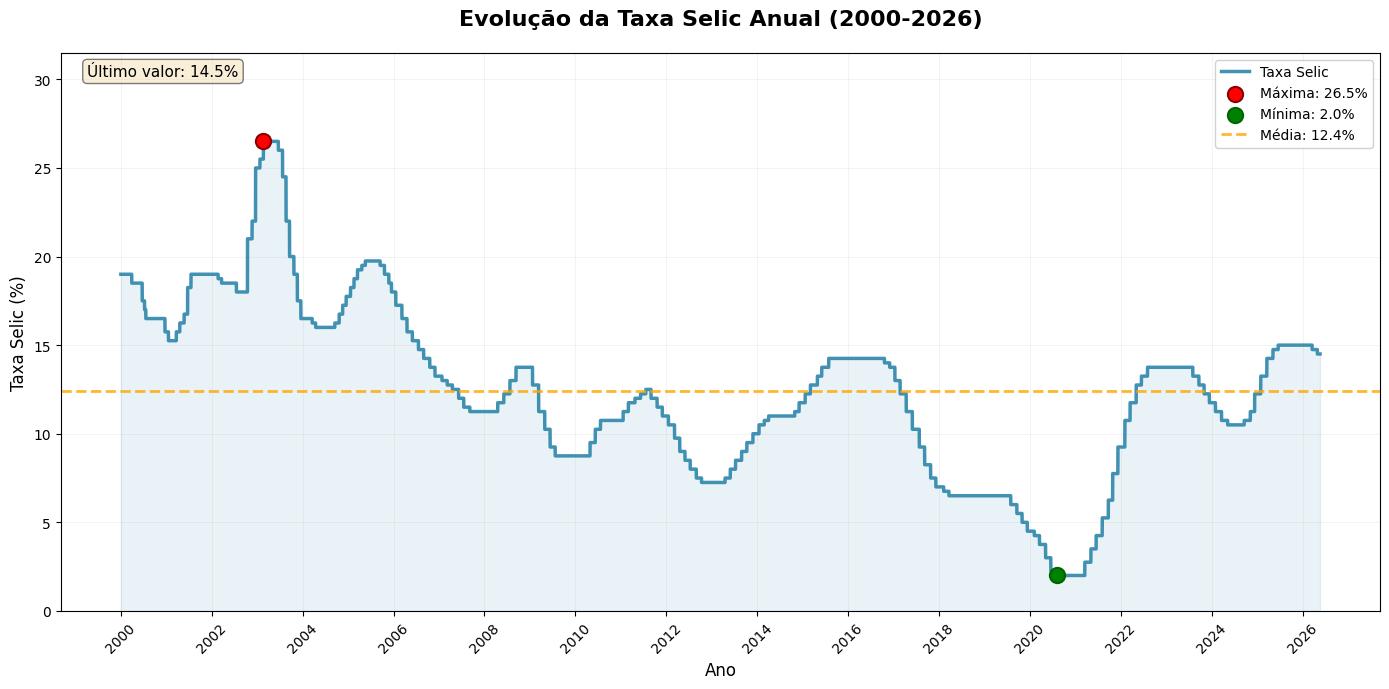

In [12]:
# Gerar grafico
fig, ax = plt.subplots(figsize=(14, 7))

# Plotar linha suave 
ax.plot(selic.index, selic['taxa_selic'], 
        linewidth=2.5, 
        color='#2E86AB',
        label='Taxa Selic',
        marker='',  # Sem marcadores
        alpha=0.9)

# Destacar máximos e mínimos 
max_valor = selic['taxa_selic'].max()
max_data = selic['taxa_selic'].idxmax()
min_valor = selic['taxa_selic'].min()
min_data = selic['taxa_selic'].idxmin()

ax.scatter(max_data, max_valor, color='red', s=120, zorder=5, 
           label=f'Máxima: {max_valor:.1f}%', edgecolors='darkred', linewidth=1.5)
ax.scatter(min_data, min_valor, color='green', s=120, zorder=5,
           label=f'Mínima: {min_valor:.1f}%', edgecolors='darkgreen', linewidth=1.5)

# Adicionar linha da média
media = selic['taxa_selic'].mean()
ax.axhline(y=media, color='orange', linestyle='--', linewidth=2,
           label=f'Média: {media:.1f}%', alpha=0.8)

# Configurar título e labels
ax.set_title('Evolução da Taxa Selic Anual (2000-2026)', 
             fontsize=16, 
             fontweight='bold',
             pad=20)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Taxa Selic (%)', fontsize=12)

# Configurar grid mais suave
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# Configurar eixo x
from matplotlib.dates import DateFormatter, YearLocator
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=45)

# Configurar eixo y
ax.set_ylim(bottom=0, top=max_valor + 5)

# Adicionar legendas
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Adicionar anotação do último valor
ax.text(0.02, 0.98, f'Último valor: {selic["taxa_selic"].iloc[-1]:.1f}%',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Adicionar área preenchida para suavizar visual
ax.fill_between(selic.index, selic['taxa_selic'], alpha=0.1, color='#2E86AB')

plt.tight_layout()
plt.show()

**Fed Funds**

In [13]:
# Estabelecer a base de dados para o FED FUND RATE
FRED_API_KEY = "1d44a916b29ea37a10f039f87bd18e99 "  
fred = Fred(api_key=FRED_API_KEY)

fedfunds = fred.get_series('FEDFUNDS', 
                            observation_start='2000-01-01',
                            observation_end=datetime.now().strftime('%Y-%m-%d'))
fedfunds = pd.DataFrame(fedfunds, columns=['taxa_fed_funds'])
fedfunds.index = pd.to_datetime(fedfunds.index)

fedfunds


,taxa_fed_funds
2000-01-01,5.45
2000-02-01,5.73
2000-03-01,5.85
2000-04-01,6.02
2000-05-01,6.27
...,...
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64


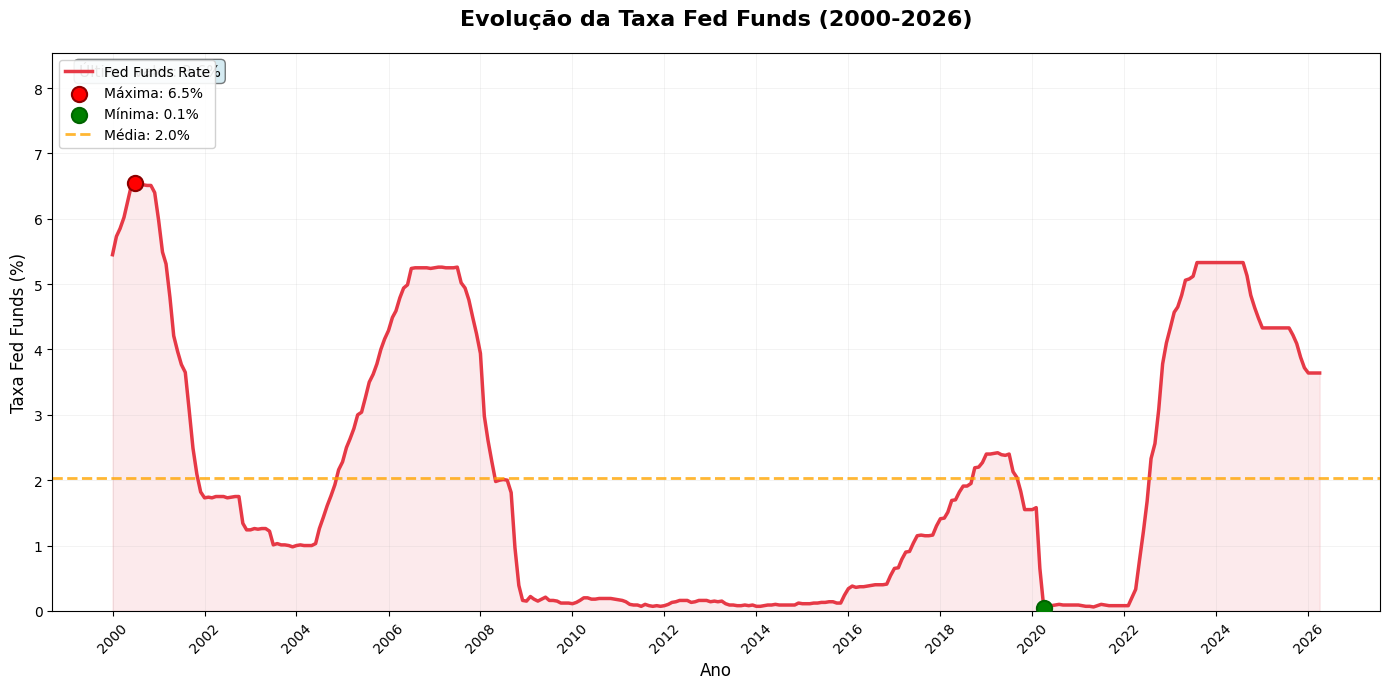

In [14]:
# Gerar gráfico para o FED FUND RATE
fig, ax = plt.subplots(figsize=(14, 7))

# Plotar linha suave 
ax.plot(fedfunds.index, fedfunds['taxa_fed_funds'], 
        linewidth=2.5, 
        color='#E63946',
        label='Fed Funds Rate',
        marker='')

# Destacar máximos e mínimos
max_valor = fedfunds['taxa_fed_funds'].max()
max_data = fedfunds['taxa_fed_funds'].idxmax()
min_valor = fedfunds['taxa_fed_funds'].min()
min_data = fedfunds['taxa_fed_funds'].idxmin()

ax.scatter(max_data, max_valor, color='red', s=120, zorder=5,
           label=f'Máxima: {max_valor:.1f}%', edgecolors='darkred', linewidth=1.5)
ax.scatter(min_data, min_valor, color='green', s=120, zorder=5,
           label=f'Mínima: {min_valor:.1f}%', edgecolors='darkgreen', linewidth=1.5)

# Linha da média
media = fedfunds['taxa_fed_funds'].mean()
ax.axhline(y=media, color='orange', linestyle='--', linewidth=2,
           label=f'Média: {media:.1f}%', alpha=0.8)

# Configurar título e labels
ax.set_title('Evolução da Taxa Fed Funds (2000-2026)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Taxa Fed Funds (%)', fontsize=12)

# Grid suave
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# Configurar eixo x
from matplotlib.dates import DateFormatter, YearLocator
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=45)

# Ajustar eixo y
ax.set_ylim(bottom=0, top=max_valor + 2)

# Legendas
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Anotação do último valor
ax.text(0.02, 0.98, f'Último valor: {fedfunds["taxa_fed_funds"].iloc[-1]:.1f}%',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Área preenchida
ax.fill_between(fedfunds.index, fedfunds['taxa_fed_funds'], alpha=0.1, color='#E63946')

plt.tight_layout()
plt.show()

# Analise Comparativa

**Estatisticas de Analise**

In [15]:
# ESTATÍSTICAS DESCRITIVAS BÁSICAS
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
print("\n" + "="*80)
print("📊 ANÁLISE DESCRITIVA COMPARATIVA")
print("Selic (Brasil) vs Fed Funds (EUA)")
print("="*80)

print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS BÁSICAS")
print("="*80)

# Criar DataFrame combinado para comparação
df_comparativo = pd.DataFrame({
    'Selic': selic['taxa_selic'],
    'FedFunds': fedfunds['taxa_fed_funds']
}).dropna()

# Estatísticas descritivas
estatisticas = df_comparativo.describe()
print("\n📈 Estatísticas Descritivas:")
print(estatisticas.round(2))

# Estatísticas adicionais
print("\n📊 Medidas Adicionais:")
print(f"{'Indicador':<25} {'Selic':<15} {'Fed Funds':<15}")
print("-" * 55)
print(f"{'Variância':<25} {df_comparativo['Selic'].var():<15.2f} {df_comparativo['FedFunds'].var():<15.2f}")
print(f"{'Desvio Padrão':<25} {df_comparativo['Selic'].std():<15.2f} {df_comparativo['FedFunds'].std():<15.2f}")
print(f"{'Assimetria (Skewness)':<25} {df_comparativo['Selic'].skew():<15.2f} {df_comparativo['FedFunds'].skew():<15.2f}")
print(f"{'Curtose (Kurtosis)':<25} {df_comparativo['Selic'].kurtosis():<15.2f} {df_comparativo['FedFunds'].kurtosis():<15.2f}")
print(f"{'Coef. Variação (%)':<25} {(df_comparativo['Selic'].std()/df_comparativo['Selic'].mean()*100):<15.1f} {(df_comparativo['FedFunds'].std()/df_comparativo['FedFunds'].mean()*100):<15.1f}")


📊 ANÁLISE DESCRITIVA COMPARATIVA
Selic (Brasil) vs Fed Funds (EUA)

ESTATÍSTICAS DESCRITIVAS BÁSICAS

📈 Estatísticas Descritivas:
        Selic  FedFunds
count  316.00    316.00
mean    12.41      2.03
std      4.89      2.03
min      2.00      0.05
25%      9.25      0.15
50%     12.25      1.28
75%     15.06      3.95
max     26.50      6.54

📊 Medidas Adicionais:
Indicador                 Selic           Fed Funds      
-------------------------------------------------------
Variância                 23.88           4.11           
Desvio Padrão             4.89            2.03           
Assimetria (Skewness)     0.22            0.69           
Curtose (Kurtosis)        0.29            -0.97          
Coef. Variação (%)        39.4            99.9           


In [16]:
# CORRELAÇÃO E RELAÇÃO ENTRE AS SÉRIES

print("\n" + "="*80)
print("2. ANÁLISE DE CORRELAÇÃO")
print("="*80)

# Correlação
correlacao = df_comparativo['Selic'].corr(df_comparativo['FedFunds'])
print(f"\n📈 Correlação de Pearson: {correlacao:.3f}")

# Correlação por período
print("\n📊 Correlação por Década:")
for decada in [2000, 2010, 2020]:
    mascara = (df_comparativo.index.year >= decada) & (df_comparativo.index.year < decada + 10)
    if mascara.any():
        corr_decada = df_comparativo.loc[mascara, 'Selic'].corr(df_comparativo.loc[mascara, 'FedFunds'])
        print(f"   {decada}s: {corr_decada:.3f}")


2. ANÁLISE DE CORRELAÇÃO

📈 Correlação de Pearson: 0.355

📊 Correlação por Década:
   2000s: -0.040
   2010s: -0.614
   2020s: 0.780


C:\Users\larry\AppData\Local\Temp\ipykernel_12344\3856451413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Taxa', y='Valor', data=df_box, palette='Set2', ax=ax)


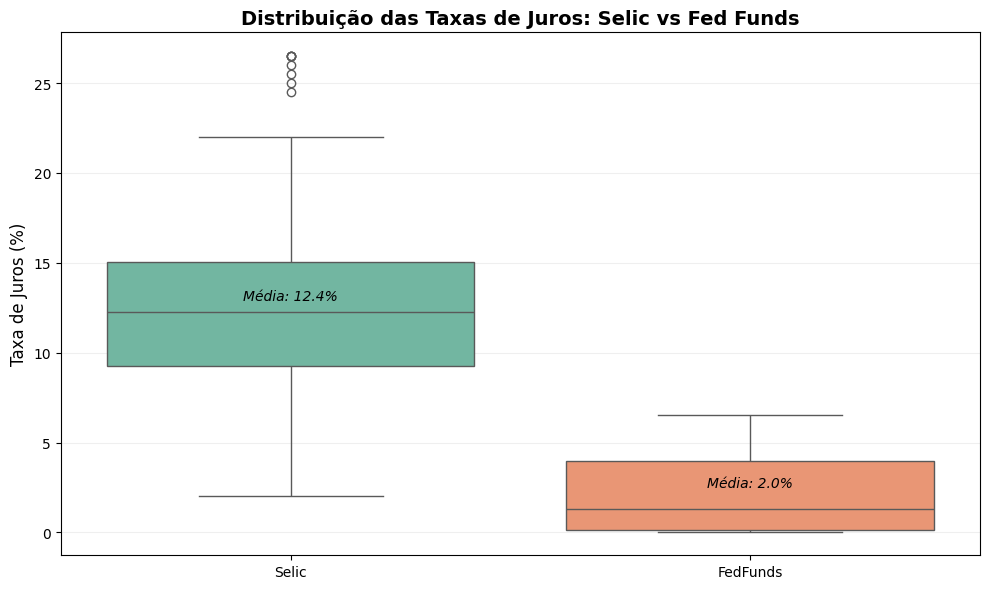

In [17]:
# BOXPLOT COMPARATIVO

fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot comparativo
df_box = df_comparativo.melt(var_name='Taxa', value_name='Valor')
sns.boxplot(x='Taxa', y='Valor', data=df_box, palette='Set2', ax=ax)

ax.set_title('Distribuição das Taxas de Juros: Selic vs Fed Funds', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa de Juros (%)', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.grid(True, alpha=0.2, axis='y')

# Adicionar estatísticas no boxplot
medias = df_comparativo.mean()
for i, taxa in enumerate(['Selic', 'FedFunds']):
    ax.text(i, medias[taxa] + 0.5, f'Média: {medias[taxa]:.1f}%', 
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

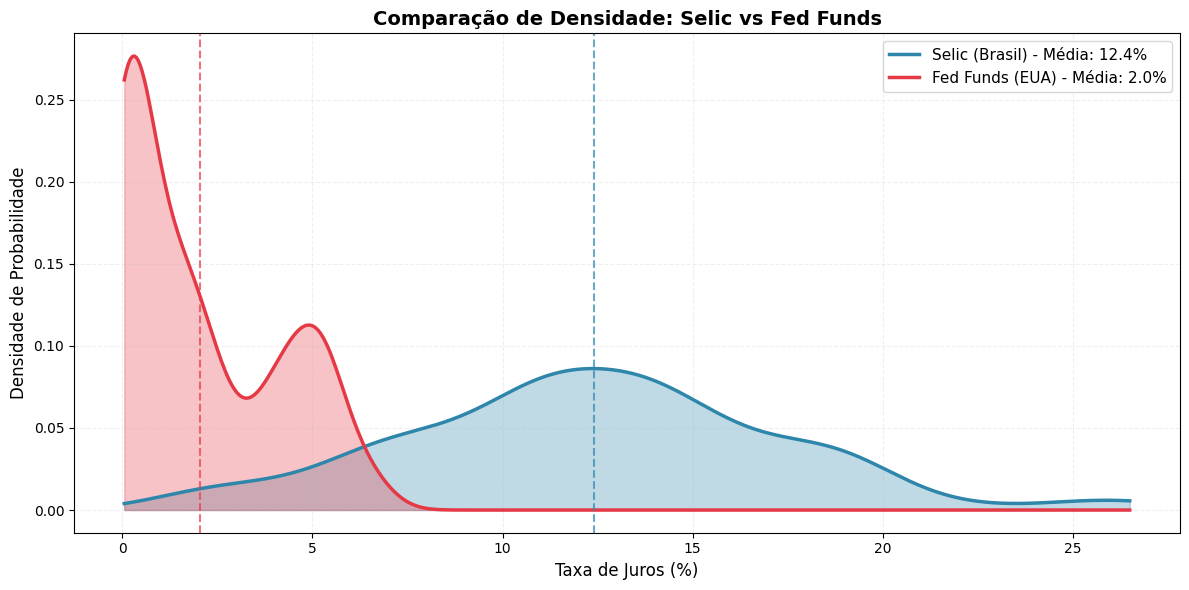

In [18]:
# FUNÇÃO COM DENSIDADE

fig2, ax2 = plt.subplots(figsize=(12, 6))

# Calcular KDE para cada série
kde_selic = gaussian_kde(df_comparativo['Selic'])
kde_fed = gaussian_kde(df_comparativo['FedFunds'])

# Criar um grid comum para ambas as séries 
x_min = min(df_comparativo['Selic'].min(), df_comparativo['FedFunds'].min())
x_max = max(df_comparativo['Selic'].max(), df_comparativo['FedFunds'].max())
x_grid = np.linspace(x_min, x_max, 500)

# Calcular densidades no grid comum
densidade_selic = kde_selic(x_grid)
densidade_fed = kde_fed(x_grid)

# Plotar as curvas de densidade
ax2.plot(x_grid, densidade_selic, color='#2E86AB', linewidth=2.5,
         label=f'Selic (Brasil) - Média: {df_comparativo["Selic"].mean():.1f}%')

ax2.plot(x_grid, densidade_fed, color='#E63946', linewidth=2.5,
         label=f'Fed Funds (EUA) - Média: {df_comparativo["FedFunds"].mean():.1f}%')

# Preencher as áreas 
ax2.fill_between(x_grid, densidade_selic, alpha=0.3, color='#2E86AB')
ax2.fill_between(x_grid, densidade_fed, alpha=0.3, color='#E63946')

# Configurar gráfico
ax2.set_title('Comparação de Densidade: Selic vs Fed Funds', fontsize=14, fontweight='bold')
ax2.set_xlabel('Taxa de Juros (%)', fontsize=12)
ax2.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.2, linestyle='--')

# Adicionar linhas verticais das médias
ax2.axvline(df_comparativo['Selic'].mean(), color='#2E86AB', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.axvline(df_comparativo['FedFunds'].mean(), color='#E63946', linestyle='--', alpha=0.7, linewidth=1.5)

plt.tight_layout()
plt.show()



3. ANÁLISE DO SPREAD (Selic - Fed Funds)
Estatísticas do Spread:
   Média: 10.38 pp
   Mediana: 10.25 pp
   Máximo: 25.28 pp
   Mínimo: 1.91 pp
   Desvio Padrão: 4.58 pp


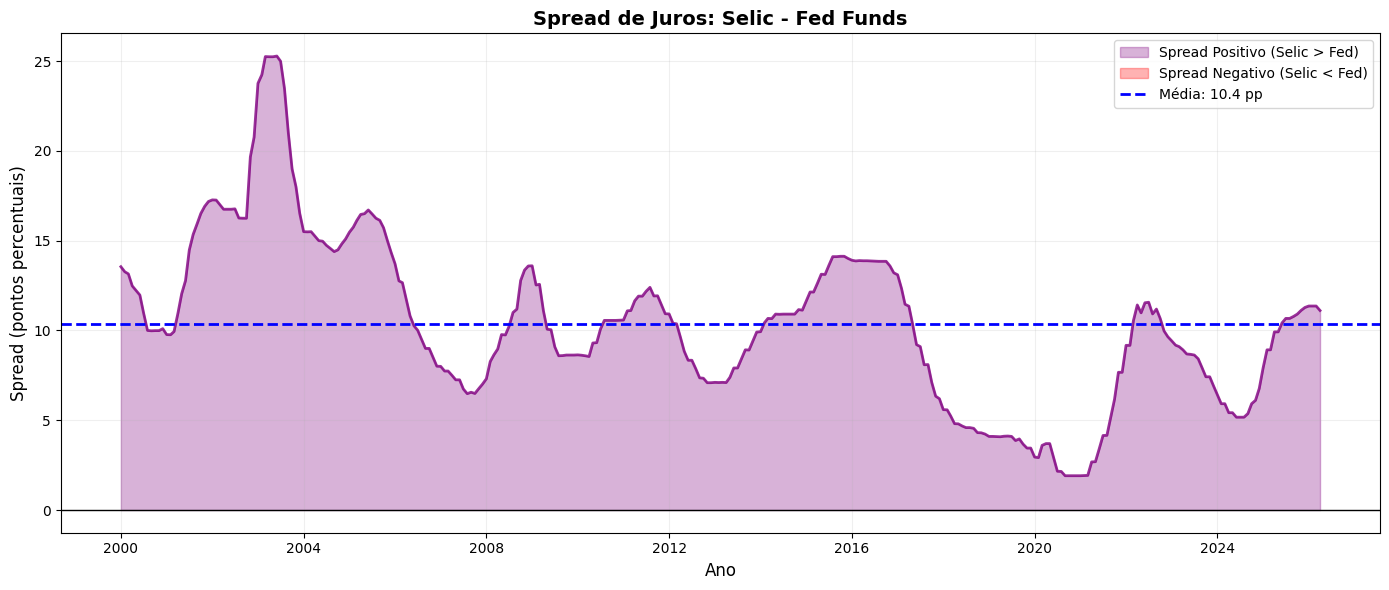

In [19]:
# ANÁLISE DE DIFERENÇA (SPREAD)

print("\n" + "="*80)
print("3. ANÁLISE DO SPREAD (Selic - Fed Funds)")
print("="*80)

# Calcular spread
df_comparativo['Spread'] = df_comparativo['Selic'] - df_comparativo['FedFunds']

# Estatísticas do spread
print(f"Estatísticas do Spread:")
print(f"   Média: {df_comparativo['Spread'].mean():.2f} pp")
print(f"   Mediana: {df_comparativo['Spread'].median():.2f} pp")
print(f"   Máximo: {df_comparativo['Spread'].max():.2f} pp")
print(f"   Mínimo: {df_comparativo['Spread'].min():.2f} pp")
print(f"   Desvio Padrão: {df_comparativo['Spread'].std():.2f} pp")

# Gráfico do spread
fig, ax = plt.subplots(figsize=(14, 6))

# Plotar spread
ax.plot(df_comparativo.index, df_comparativo['Spread'], 
        linewidth=2, color='purple', marker='', alpha=0.8)

# Área preenchida
ax.fill_between(df_comparativo.index, df_comparativo['Spread'], 0, 
                alpha=0.3, color='purple', 
                where=(df_comparativo['Spread'] > 0), label='Spread Positivo (Selic > Fed)',
                interpolate=True)
ax.fill_between(df_comparativo.index, df_comparativo['Spread'], 0, 
                alpha=0.3, color='red',
                where=(df_comparativo['Spread'] < 0), label='Spread Negativo (Selic < Fed)',
                interpolate=True)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Linha da média
ax.axhline(y=df_comparativo['Spread'].mean(), color='blue', linestyle='--', linewidth=2,
           label=f'Média: {df_comparativo["Spread"].mean():.1f} pp')

ax.set_title('Spread de Juros: Selic - Fed Funds', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Spread (pontos percentuais)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**Extrair as series**

In [20]:
# Padronizar formato
df_selic = pd.DataFrame({
    'Data': selic.index,
    'Taxa_Selic': selic['taxa_selic'].values
})

df_fed = pd.DataFrame({
    'Data': fedfunds.index,
    'Taxa_Fed_Funds': fedfunds['taxa_fed_funds'].values
})

df_conjunto = pd.DataFrame({
    'Data': df_comparativo.index,
    'Selic_Brasil': df_comparativo['Selic'].values,
    'Fed_Funds_EUA': df_comparativo['FedFunds'].values,
})

# Salvar arquivos CSV
df_selic.to_csv('selic_brasil.csv', index=False)
df_fed.to_csv('fedfunds_eua.csv', index=False)
df_conjunto.to_csv('comparativo_selic_fedfunds.csv', index=False)

# Produção Industrial
**Obter dados**

In [21]:
# Produção industrial americana
FRED_API_KEY = "1d44a916b29ea37a10f039f87bd18e99"  
fred = Fred(api_key=FRED_API_KEY)
ind_eua_s = fred.get_series('INDPRO', 
                            observation_start='2002-01-01',
                            observation_end="2022-12-31")
ind_eua_s = pd.DataFrame(ind_eua_s, columns=['taxa_indpro_eua_s'])
ind_eua_s.index = pd.to_datetime(ind_eua_s.index)

ind_eua_ns = fred.get_series('IPB50001N', 
                            observation_start='2002-01-01',
                            observation_end="2022-12-31")
ind_eua_ns = pd.DataFrame(ind_eua_ns, columns=['taxa_indpro_eua_ns'])
ind_eua_ns.index = pd.to_datetime(ind_eua_ns.index)


print(ind_eua_s)

print(ind_eua_ns)

            taxa_indpro_eua_s
2002-01-01            88.5176
2002-02-01            88.5278
2002-03-01            89.1686
2002-04-01            89.6040
2002-05-01            89.9640
...                       ...
2022-08-01           101.0963
2022-09-01           101.2918
2022-10-01           101.2529
2022-11-01           100.9552
2022-12-01            99.7664

[252 rows x 1 columns]
            taxa_indpro_eua_ns
2002-01-01             87.5924
2002-02-01             88.2280
2002-03-01             89.6016
2002-04-01             88.7504
2002-05-01             89.1815
...                        ...
2022-08-01            102.9905
2022-09-01            101.3846
2022-10-01            100.8736
2022-11-01            100.3301
2022-12-01             99.6085

[252 rows x 1 columns]


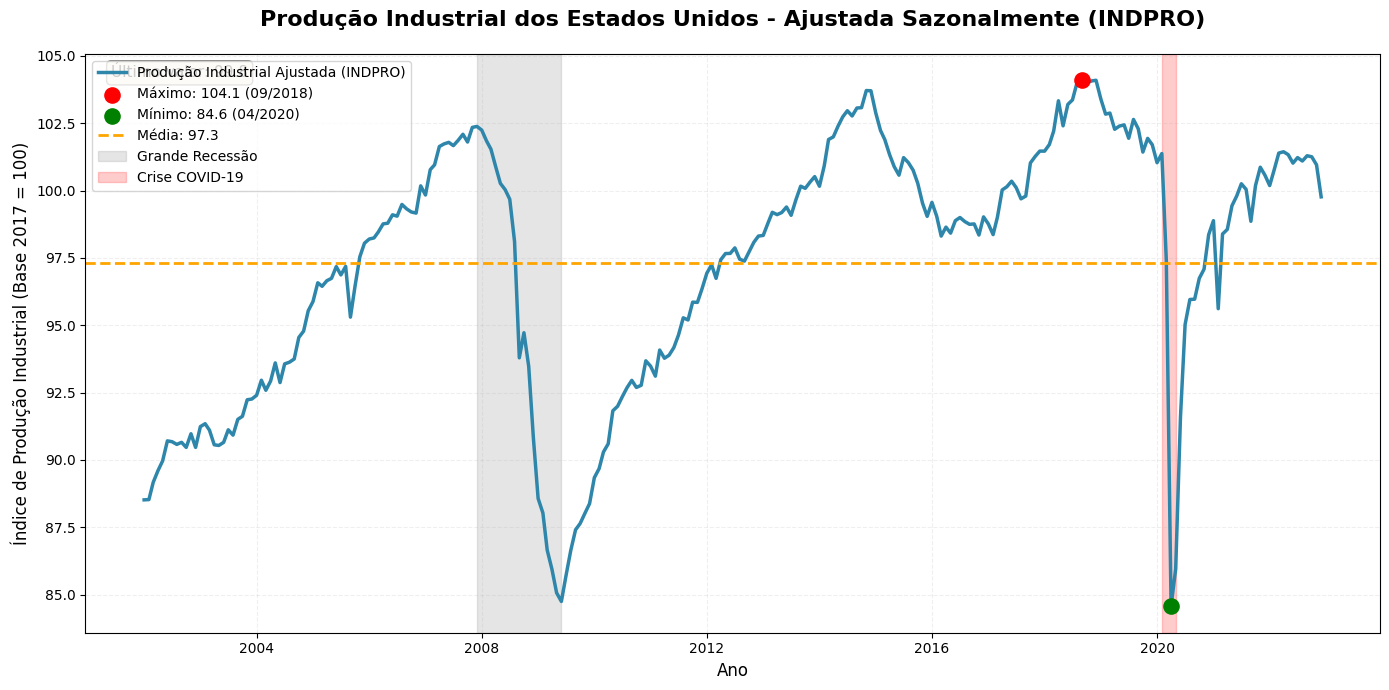

In [22]:
# Grafico produção industrial americana sazonalmente ajustada

fig1, ax1 = plt.subplots(figsize=(14, 7))

# Linha principal
ax1.plot(ind_eua_s.index, ind_eua_s['taxa_indpro_eua_s'], 
        linewidth=2.5, 
        color='#2E86AB',
        label='Produção Industrial Ajustada (INDPRO)')

# Destacar máximos e mínimos
max_valor1 = ind_eua_s['taxa_indpro_eua_s'].max()
max_data1 = ind_eua_s['taxa_indpro_eua_s'].idxmax()
min_valor1 = ind_eua_s['taxa_indpro_eua_s'].min()
min_data1 = ind_eua_s['taxa_indpro_eua_s'].idxmin()

ax1.scatter(max_data1, max_valor1, color='red', s=120, zorder=5,
           label=f'Máximo: {max_valor1:.1f} ({max_data1.strftime("%m/%Y")})')
ax1.scatter(min_data1, min_valor1, color='green', s=120, zorder=5,
           label=f'Mínimo: {min_valor1:.1f} ({min_data1.strftime("%m/%Y")})')

# Linha da média
media1 = ind_eua_s['taxa_indpro_eua_s'].mean()
ax1.axhline(y=media1, color='orange', linestyle='--', linewidth=2,
           label=f'Média: {media1:.1f}')

# Área de recessão (2008, 2020)
ax1.axvspan(datetime(2007, 12, 1), datetime(2009, 6, 1), 
           alpha=0.2, color='gray', label='Grande Recessão')
ax1.axvspan(datetime(2020, 2, 1), datetime(2020, 5, 1), 
           alpha=0.2, color='red', label='Crise COVID-19')

# Configurar título e labels
ax1.set_title('Produção Industrial dos Estados Unidos - Ajustada Sazonalmente (INDPRO)', 
             fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Índice de Produção Industrial (Base 2017 = 100)', fontsize=12)

# Configurar grid
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.legend(loc='upper left', fontsize=10)

# Anotação do último valor
ax1.text(0.02, 0.98, f'Último valor: {ind_eua_s["taxa_indpro_eua_s"].iloc[-1]:.1f}',
        transform=ax1.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

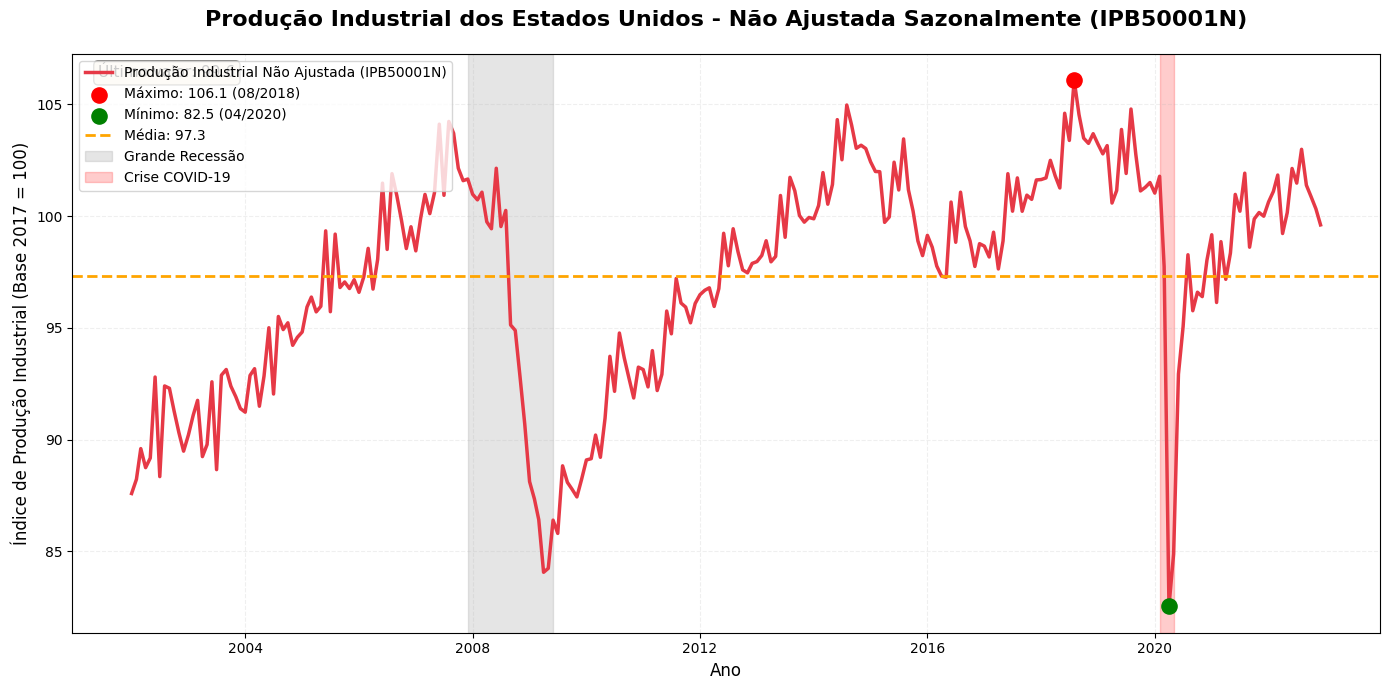

In [23]:
# Grafico produção industrial americana não ajustada
fig2, ax2 = plt.subplots(figsize=(14, 7))

# Linha principal
ax2.plot(ind_eua_ns.index, ind_eua_ns['taxa_indpro_eua_ns'], 
        linewidth=2.5, 
        color='#E63946',
        label='Produção Industrial Não Ajustada (IPB50001N)')

# Destacar máximos e mínimos
max_valor2 = ind_eua_ns['taxa_indpro_eua_ns'].max()
max_data2 = ind_eua_ns['taxa_indpro_eua_ns'].idxmax()
min_valor2 = ind_eua_ns['taxa_indpro_eua_ns'].min()
min_data2 = ind_eua_ns['taxa_indpro_eua_ns'].idxmin()

ax2.scatter(max_data2, max_valor2, color='red', s=120, zorder=5,
           label=f'Máximo: {max_valor2:.1f} ({max_data2.strftime("%m/%Y")})')
ax2.scatter(min_data2, min_valor2, color='green', s=120, zorder=5,
           label=f'Mínimo: {min_valor2:.1f} ({min_data2.strftime("%m/%Y")})')

# Linha da média
media2 = ind_eua_ns['taxa_indpro_eua_ns'].mean()
ax2.axhline(y=media2, color='orange', linestyle='--', linewidth=2,
           label=f'Média: {media2:.1f}')

# Área de recessão (2008, 2020)
ax2.axvspan(datetime(2007, 12, 1), datetime(2009, 6, 1), 
           alpha=0.2, color='gray', label='Grande Recessão')
ax2.axvspan(datetime(2020, 2, 1), datetime(2020, 5, 1), 
           alpha=0.2, color='red', label='Crise COVID-19')

# Configurar título e labels
ax2.set_title('Produção Industrial dos Estados Unidos - Não Ajustada Sazonalmente (IPB50001N)', 
             fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Índice de Produção Industrial (Base 2017 = 100)', fontsize=12)

# Configurar grid
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.legend(loc='upper left', fontsize=10)

# Anotação do último valor
ax2.text(0.02, 0.98, f'Último valor: {ind_eua_ns["taxa_indpro_eua_ns"].iloc[-1]:.1f}',
        transform=ax2.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [24]:
# Produção industrial brasileira
ind_br = sidrapy.get_table(
    table_code='8159',
    territorial_level='1',
    ibge_territorial_code='1',
    period='200001-202604'
)
ind_br = ind_br.drop(ind_br.columns[0:4], axis=1)
ind_br = ind_br.drop(ind_br.columns[1:3], axis=1)
ind_br = ind_br.drop(ind_br.columns[2], axis=1)
ultima_coluna = ind_br.columns[-1]
ind_br = ind_br[ind_br[ultima_coluna] == '1 Indústria geral']
ind_br = ind_br.iloc[:, :-2]

ind_br_ns = ind_br[ind_br["D3C"] == '11599'].copy()
ind_br_ns = ind_br_ns.drop(ind_br_ns.columns[2:4], axis=1)
ind_br_ns = ind_br_ns.rename(columns={
    ind_br_ns.columns[0]: 'taxa_indpro_br_ns',
    ind_br_ns.columns[1]: 'data_codigo'
})
ind_br_ns['data'] = pd.to_datetime(ind_br_ns['data_codigo'], format='%Y%m')
ind_br_ns['data_formatada'] = ind_br_ns['data'].dt.strftime('%d/%m/%Y')
ind_br_ns_clean = pd.DataFrame({
    'data': ind_br_ns['data'],
    'taxa_indpro_br_ns': ind_br_ns['taxa_indpro_br_ns']
})
ind_br_ns= ind_br_ns_clean.sort_values('data').reset_index(drop=True)
ind_br_ns = ind_br_ns.set_index('data').sort_index()
ind_br_ns.index = pd.to_datetime(ind_br_ns.index)
ind_br_ns = ind_br_ns.sort_index()
ind_br_ns['taxa_indpro_br_ns'] = pd.to_numeric(ind_br_ns['taxa_indpro_br_ns'], errors='coerce')


ind_br_s = ind_br[ind_br["D3C"] == '11600'].copy()
ind_br_s = ind_br_s.drop(ind_br_s.columns[2:4], axis=1)
ind_br_s = ind_br_s.rename(columns={
    ind_br_s.columns[0]: 'taxa_indpro_br_s',
    ind_br_s.columns[1]: 'data_codigo'
})
ind_br_s['data'] = pd.to_datetime(ind_br_s['data_codigo'], format='%Y%m')
ind_br_s['data_formatada'] = ind_br_s['data'].dt.strftime('%d/%m/%Y')
ind_br_s_clean = pd.DataFrame({
    'data': ind_br_s['data'],
    'taxa_indpro_br_s': ind_br_s['taxa_indpro_br_s']
})
ind_br_s = ind_br_s_clean.sort_values('data').reset_index(drop=True)
ind_br_s = ind_br_s.set_index('data').sort_index()
ind_br_s.index = pd.to_datetime(ind_br_s.index)
ind_br_s = ind_br_s.sort_index()
ind_br_s['taxa_indpro_br_s'] = pd.to_numeric(ind_br_s['taxa_indpro_br_s'], errors='coerce')

print(ind_br_ns)
print(ind_br_s)

            taxa_indpro_br_ns
data                         
2002-01-01           72.39269
2002-02-01           69.71441
2002-03-01           77.39979
2002-04-01           79.59671
2002-05-01           80.44721
...                       ...
2022-08-01           95.95352
2022-09-01           91.81049
2022-10-01           91.26549
2022-11-01           87.03596
2022-12-01           78.21171

[252 rows x 1 columns]
            taxa_indpro_br_s
data                        
2002-01-01          77.87338
2002-02-01          79.80332
2002-03-01          79.30592
2002-04-01          79.39795
2002-05-01          79.36153
...                      ...
2022-08-01          86.03388
2022-09-01          85.43574
2022-10-01          85.67647
2022-11-01          85.59389
2022-12-01          85.61360

[252 rows x 1 columns]


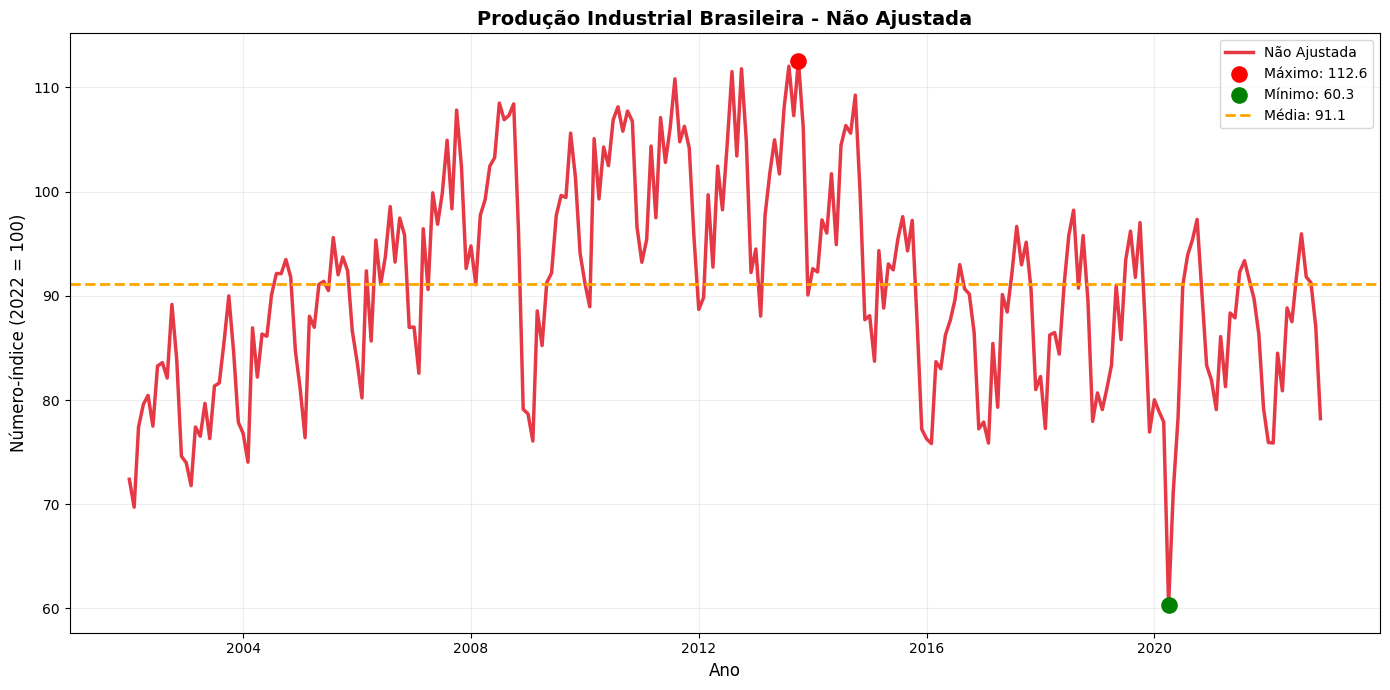

In [25]:
# Gráfico produção industrial brasileira não ajustada
fig1, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(ind_br_ns.index, ind_br_ns['taxa_indpro_br_ns'], 
         linewidth=2.5, color='#E63946', label='Não Ajustada')

# Destaques
max_valor_ns = ind_br_ns['taxa_indpro_br_ns'].max()
max_data_ns = ind_br_ns['taxa_indpro_br_ns'].idxmax()
min_valor_ns = ind_br_ns['taxa_indpro_br_ns'].min()
min_data_ns = ind_br_ns['taxa_indpro_br_ns'].idxmin()
media_ns = ind_br_ns['taxa_indpro_br_ns'].mean()

ax1.scatter(max_data_ns, max_valor_ns, color='red', s=120, zorder=5,
           label=f'Máximo: {max_valor_ns:.1f}')
ax1.scatter(min_data_ns, min_valor_ns, color='green', s=120, zorder=5,
           label=f'Mínimo: {min_valor_ns:.1f}')
ax1.axhline(y=media_ns, color='orange', linestyle='--', linewidth=2,
           label=f'Média: {media_ns:.1f}')

ax1.set_title('Produção Industrial Brasileira - Não Ajustada', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Número-índice (2022 = 100)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

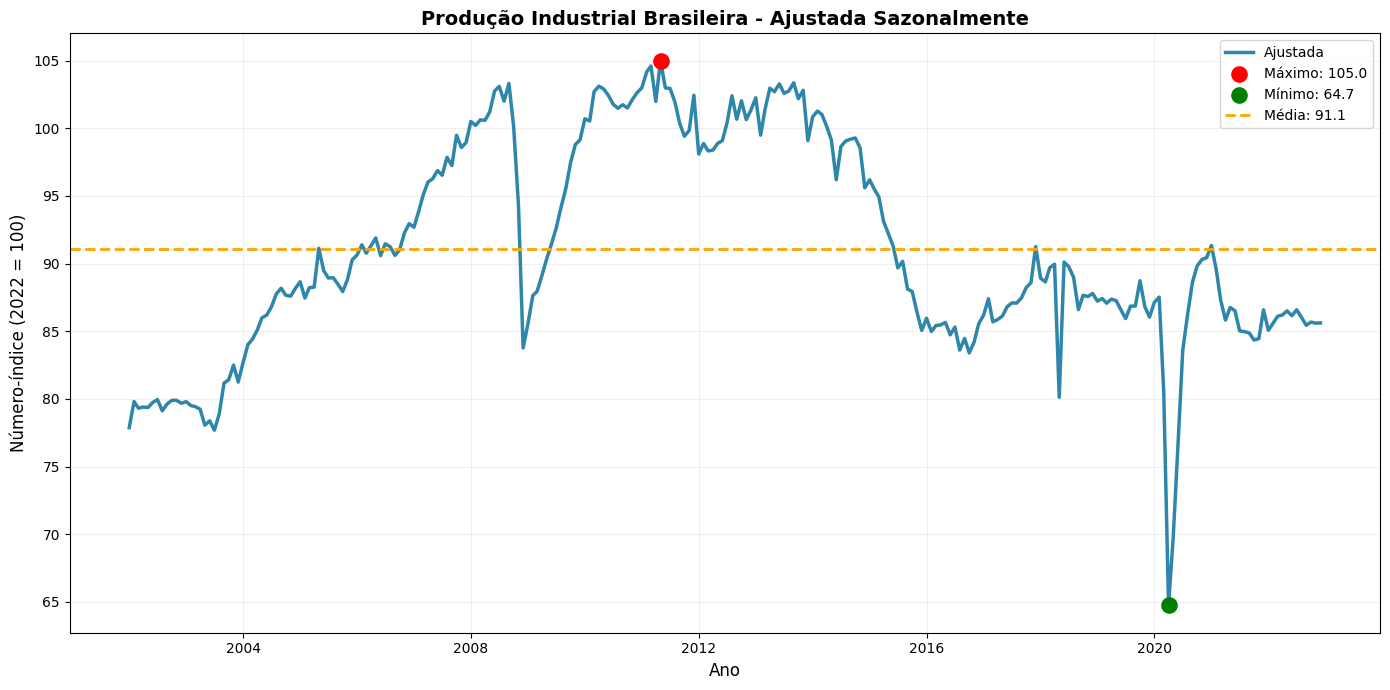

In [26]:
# Gráfico para a produção industrial brasileira ajustada sazonalmente
fig2, ax2 = plt.subplots(figsize=(14, 7))

ax2.plot(ind_br_s.index, ind_br_s['taxa_indpro_br_s'], 
         linewidth=2.5, color='#2E86AB', label='Ajustada')

max_valor_s = ind_br_s['taxa_indpro_br_s'].max()
max_data_s = ind_br_s['taxa_indpro_br_s'].idxmax()
min_valor_s = ind_br_s['taxa_indpro_br_s'].min()
min_data_s = ind_br_s['taxa_indpro_br_s'].idxmin()
media_s = ind_br_s['taxa_indpro_br_s'].mean()

ax2.scatter(max_data_s, max_valor_s, color='red', s=120, zorder=5,
           label=f'Máximo: {max_valor_s:.1f}')
ax2.scatter(min_data_s, min_valor_s, color='green', s=120, zorder=5,
           label=f'Mínimo: {min_valor_s:.1f}')
ax2.axhline(y=media_s, color='orange', linestyle='--', linewidth=2,
           label=f'Média: {media_s:.1f}')

ax2.set_title('Produção Industrial Brasileira - Ajustada Sazonalmente', 
             fontsize=14, fontweight='bold')
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Número-índice (2022 = 100)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**Comparação**

In [27]:
# Preparar analise comparativa entre Brasil e EUA
ind_br_ns.index = pd.to_datetime(ind_br_ns.index)
ind_br_s.index = pd.to_datetime(ind_br_s.index)
ind_eua_ns.index = pd.to_datetime(ind_eua_ns.index)
ind_eua_s.index = pd.to_datetime(ind_eua_s.index)

ind_br_ns = ind_br_ns.rename(columns={'taxa_indpro_br_ns': 'Brasil_NS'})
ind_br_s = ind_br_s.rename(columns={'taxa_indpro_br_s': 'Brasil_S'})
ind_eua_ns = ind_eua_ns.rename(columns={'taxa_indpro_eua_ns': 'EUA_NS'})
ind_eua_s = ind_eua_s.rename(columns={'taxa_indpro_eua_s': 'EUA_S'})

df_industrial = pd.DataFrame({
    'Brasil_NS': ind_br_ns['Brasil_NS'],
    'Brasil_S': ind_br_s['Brasil_S'],
    'EUA_NS': ind_eua_ns['EUA_NS'],
    'EUA_S': ind_eua_s['EUA_S']
}).dropna()

df_industrial

,Brasil_NS,Brasil_S,EUA_NS,EUA_S
2002-01-01,72.39269,77.87338,87.5924,88.5176
2002-02-01,69.71441,79.80332,88.2280,88.5278
2002-03-01,77.39979,79.30592,89.6016,89.1686
2002-04-01,79.59671,79.39795,88.7504,89.6040
2002-05-01,80.44721,79.36153,89.1815,89.9640
...,...,...,...,...
2022-08-01,95.95352,86.03388,102.9905,101.0963
2022-09-01,91.81049,85.43574,101.3846,101.2918
2022-10-01,91.26549,85.67647,100.8736,101.2529
2022-11-01,87.03596,85.59389,100.3301,100.9552


In [28]:
# Analise descritiva base
print("="*80)
print("ANÁLISE DESCRITIVA - PRODUÇÃO INDUSTRIAL")
print("Brasil vs Estados Unidos (2002-2022)")
print("="*80)

print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*80)

estatisticas = df_industrial.describe()
print("\nTabela de Estatísticas:")
print(estatisticas.round(2))

print("\nMedidas Adicionais:")
print(f"{'Indicador':<25} {'Brasil_NS':<15} {'Brasil_S':<15} {'EUA_NS':<15} {'EUA_S':<15}")
print("-" * 75)
print(f"{'Variância':<25} {df_industrial['Brasil_NS'].var():<15.2f} {df_industrial['Brasil_S'].var():<15.2f} {df_industrial['EUA_NS'].var():<15.2f} {df_industrial['EUA_S'].var():<15.2f}")
print(f"{'Desvio Padrão':<25} {df_industrial['Brasil_NS'].std():<15.2f} {df_industrial['Brasil_S'].std():<15.2f} {df_industrial['EUA_NS'].std():<15.2f} {df_industrial['EUA_S'].std():<15.2f}")
print(f"{'Assimetria':<25} {df_industrial['Brasil_NS'].skew():<15.2f} {df_industrial['Brasil_S'].skew():<15.2f} {df_industrial['EUA_NS'].skew():<15.2f} {df_industrial['EUA_S'].skew():<15.2f}")
print(f"{'Curtose':<25} {df_industrial['Brasil_NS'].kurtosis():<15.2f} {df_industrial['Brasil_S'].kurtosis():<15.2f} {df_industrial['EUA_NS'].kurtosis():<15.2f} {df_industrial['EUA_S'].kurtosis():<15.2f}")
print(f"{'CV (%)':<25} {(df_industrial['Brasil_NS'].std()/df_industrial['Brasil_NS'].mean()*100):<15.1f} {(df_industrial['Brasil_S'].std()/df_industrial['Brasil_S'].mean()*100):<15.1f} {(df_industrial['EUA_NS'].std()/df_industrial['EUA_NS'].mean()*100):<15.1f} {(df_industrial['EUA_S'].std()/df_industrial['EUA_S'].mean()*100):<15.1f}")


ANÁLISE DESCRITIVA - PRODUÇÃO INDUSTRIAL
Brasil vs Estados Unidos (2002-2022)

ESTATÍSTICAS DESCRITIVAS

Tabela de Estatísticas:
       Brasil_NS  Brasil_S  EUA_NS   EUA_S
count     252.00    252.00  252.00  252.00
mean       91.09     91.09   97.32   97.32
std         9.85      7.74    4.85    4.70
min        60.28     64.73   82.54   84.56
25%        83.72     85.95   94.16   93.73
50%        91.16     88.97   98.53   98.76
75%        97.47     98.97  101.06  101.03
max       112.58    105.00  106.09  104.10

Medidas Adicionais:
Indicador                 Brasil_NS       Brasil_S        EUA_NS          EUA_S          
---------------------------------------------------------------------------
Variância                 97.10           59.97           23.55           22.07          
Desvio Padrão             9.85            7.74            4.85            4.70           
Assimetria                0.00            -0.00           -0.75           -0.77          
Curtose                   -

In [29]:
# Analise de momentos históricos
print("\n" + "="*80)
print("MOMENTOS HISTÓRICOS")
print("="*80)

print("\nMaiores valores históricos:")
print(f"   Brasil (NS): {df_industrial['Brasil_NS'].max():.2f} em {df_industrial['Brasil_NS'].idxmax().strftime('%b/%Y')}")
print(f"   Brasil (S):  {df_industrial['Brasil_S'].max():.2f} em {df_industrial['Brasil_S'].idxmax().strftime('%b/%Y')}")
print(f"   EUA (NS):    {df_industrial['EUA_NS'].max():.2f} em {df_industrial['EUA_NS'].idxmax().strftime('%b/%Y')}")
print(f"   EUA (S):     {df_industrial['EUA_S'].max():.2f} em {df_industrial['EUA_S'].idxmax().strftime('%b/%Y')}")

print("\nMenores valores históricos:")
print(f"   Brasil (NS): {df_industrial['Brasil_NS'].min():.2f} em {df_industrial['Brasil_NS'].idxmin().strftime('%b/%Y')}")
print(f"   Brasil (S):  {df_industrial['Brasil_S'].min():.2f} em {df_industrial['Brasil_S'].idxmin().strftime('%b/%Y')}")
print(f"   EUA (NS):    {df_industrial['EUA_NS'].min():.2f} em {df_industrial['EUA_NS'].idxmin().strftime('%b/%Y')}")
print(f"   EUA (S):     {df_industrial['EUA_S'].min():.2f} em {df_industrial['EUA_S'].idxmin().strftime('%b/%Y')}")



MOMENTOS HISTÓRICOS

Maiores valores históricos:
   Brasil (NS): 112.58 em Oct/2013
   Brasil (S):  105.00 em May/2011
   EUA (NS):    106.09 em Aug/2018
   EUA (S):     104.10 em Sep/2018

Menores valores históricos:
   Brasil (NS): 60.28 em Apr/2020
   Brasil (S):  64.73 em Apr/2020
   EUA (NS):    82.54 em Apr/2020
   EUA (S):     84.56 em Apr/2020


In [30]:
# Analise por decadas
df_industrial['decada'] = (df_industrial.index.year // 10) * 10

print("\n" + "="*80)
print("MÉDIA POR DÉCADA")
print("="*80)

for decada in sorted(df_industrial['decada'].unique()):
    dados_decada = df_industrial[df_industrial['decada'] == decada]
    print(f"\nDécada de {decada}:")
    print(f"   Brasil NS: {dados_decada['Brasil_NS'].mean():.2f}")
    print(f"   Brasil S:  {dados_decada['Brasil_S'].mean():.2f}")
    print(f"   EUA NS:    {dados_decada['EUA_NS'].mean():.2f}")
    print(f"   EUA S:     {dados_decada['EUA_S'].mean():.2f}")



MÉDIA POR DÉCADA

Década de 2000:
   Brasil NS: 89.29
   Brasil S:  89.27
   EUA NS:    94.65
   EUA S:     94.65

Década de 2010:
   Brasil NS: 94.33
   Brasil S:  94.35
   EUA NS:    99.11
   EUA S:     99.11

Década de 2020:
   Brasil NS: 85.13
   Brasil S:  85.10
   EUA NS:    98.45
   EUA S:     98.45


In [31]:
# Analise de correlação
print("\n" + "="*80)
print("MATRIZ DE CORRELAÇÃO")
print("="*80)

correlacao = df_industrial[['Brasil_NS', 'Brasil_S', 'EUA_NS', 'EUA_S']].corr()
print("\nMatriz de Correlação:")
print(correlacao.round(4))



MATRIZ DE CORRELAÇÃO

Matriz de Correlação:
           Brasil_NS  Brasil_S  EUA_NS   EUA_S
Brasil_NS     1.0000    0.7979  0.2258  0.1683
Brasil_S      0.7979    1.0000  0.2032  0.1986
EUA_NS        0.2258    0.2032  1.0000  0.9735
EUA_S         0.1683    0.1986  0.9735  1.0000


C:\Users\larry\AppData\Local\Temp\ipykernel_12344\1218532406.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Série', y='Valor', data=df_box_completo, palette='Set2', ax=ax2)


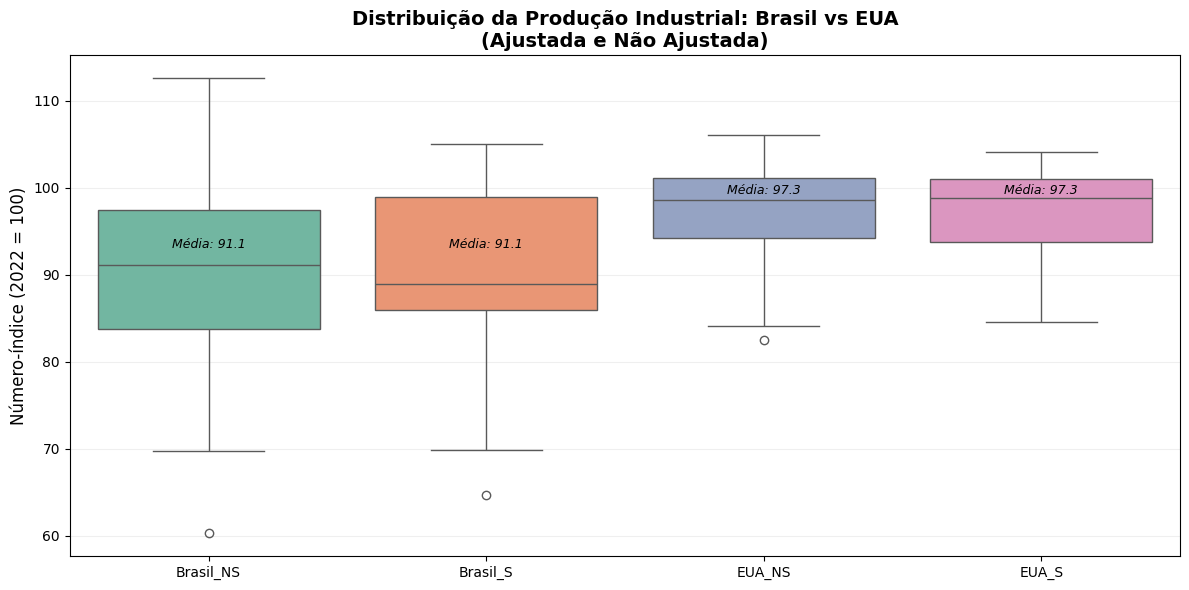

In [32]:
# Boxplot comparativo para as séries de produção industrial
df_box_completo = df_industrial[['Brasil_NS', 'Brasil_S', 'EUA_NS', 'EUA_S']].melt(var_name='Série', value_name='Valor')

fig2, ax2 = plt.subplots(figsize=(12, 6))

sns.boxplot(x='Série', y='Valor', data=df_box_completo, palette='Set2', ax=ax2)

ax2.set_title('Distribuição da Produção Industrial: Brasil vs EUA\n(Ajustada e Não Ajustada)', 
             fontsize=14, fontweight='bold')
ax2.set_ylabel('Número-índice (2022 = 100)', fontsize=12)
ax2.set_xlabel('', fontsize=12)
ax2.grid(True, alpha=0.2, axis='y')

# Adicionar médias
medias_completas = {
    'Brasil_NS': df_industrial['Brasil_NS'].mean(),
    'Brasil_S': df_industrial['Brasil_S'].mean(),
    'EUA_NS': df_industrial['EUA_NS'].mean(),
    'EUA_S': df_industrial['EUA_S'].mean()
}

for i, serie in enumerate(['Brasil_NS', 'Brasil_S', 'EUA_NS', 'EUA_S']):
    ax2.text(i, medias_completas[serie] + 2, f'Média: {medias_completas[serie]:.1f}', 
             ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()


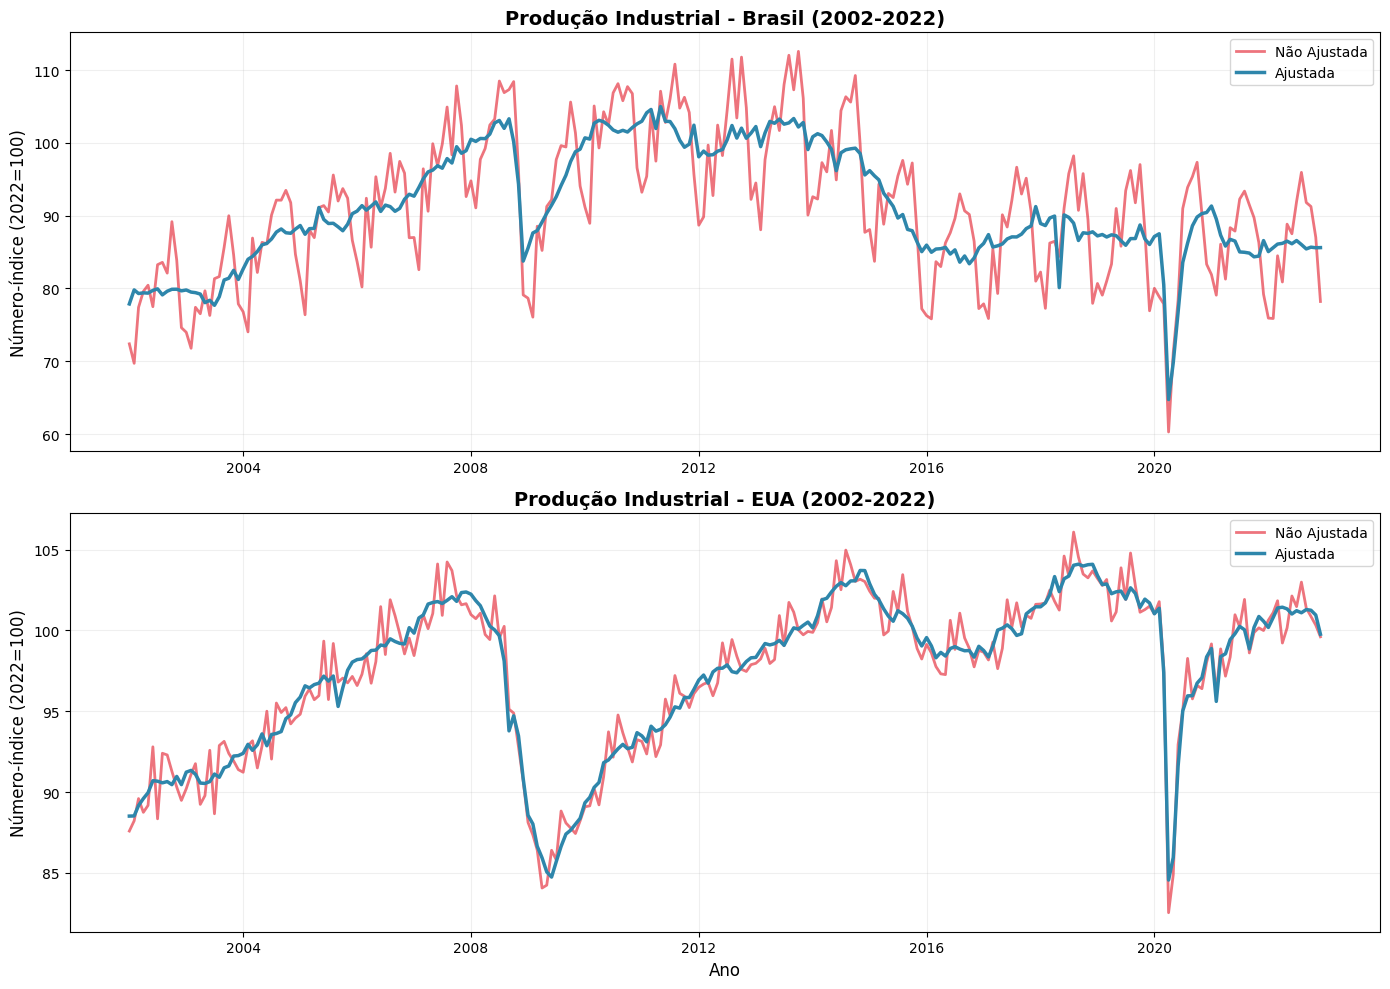

In [33]:
# Grafico comparativos
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10))

# Brasil
axes2[0].plot(df_industrial.index, df_industrial['Brasil_NS'], 
             linewidth=2, color='#E63946', alpha=0.7, label='Não Ajustada')
axes2[0].plot(df_industrial.index, df_industrial['Brasil_S'], 
             linewidth=2.5, color='#2E86AB', label='Ajustada')
axes2[0].set_title('Produção Industrial - Brasil (2002-2022)', fontsize=14, fontweight='bold')
axes2[0].set_ylabel('Número-índice (2022=100)', fontsize=12)
axes2[0].legend()
axes2[0].grid(True, alpha=0.2)

# EUA
axes2[1].plot(df_industrial.index, df_industrial['EUA_NS'], 
             linewidth=2, color='#E63946', alpha=0.7, label='Não Ajustada')
axes2[1].plot(df_industrial.index, df_industrial['EUA_S'], 
             linewidth=2.5, color='#2E86AB', label='Ajustada')
axes2[1].set_title('Produção Industrial - EUA (2002-2022)', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Ano', fontsize=12)
axes2[1].set_ylabel('Número-índice (2022=100)', fontsize=12)
axes2[1].legend()
axes2[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


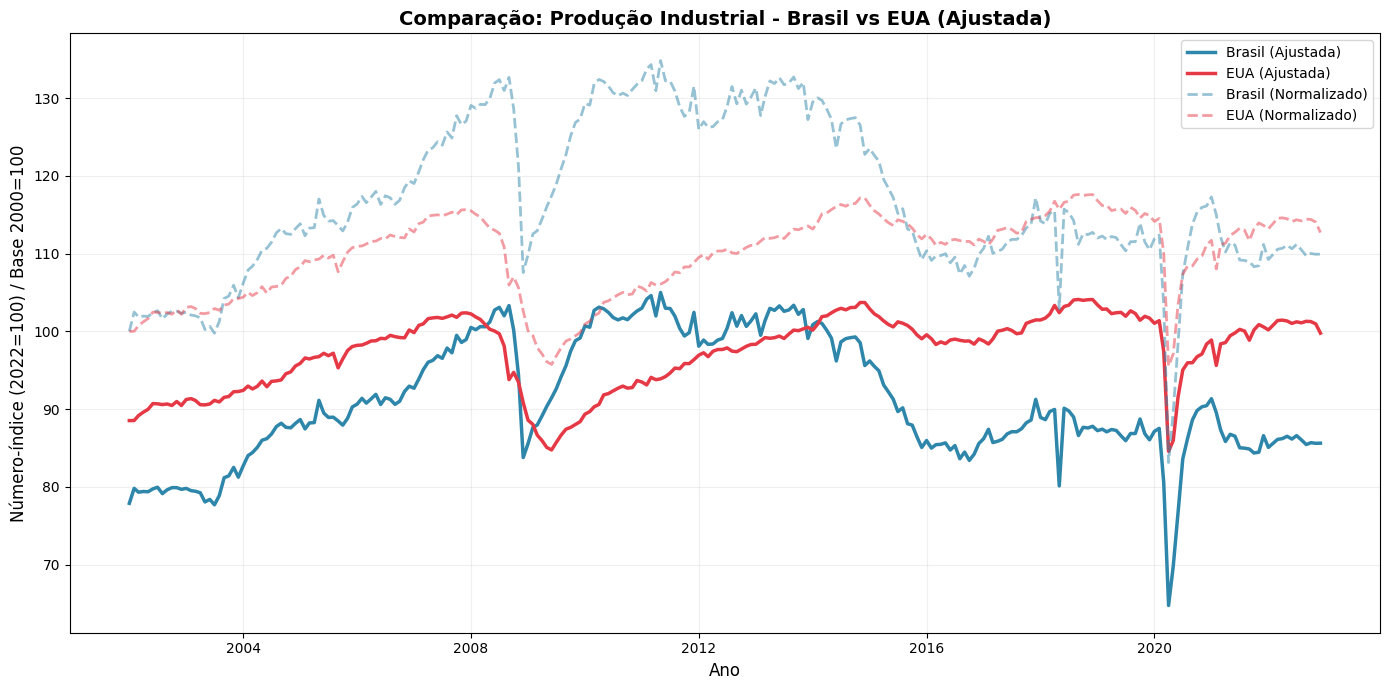

In [34]:
# Graficos comparativos lado a lado para Brasil e EUA (ajustados e normalizados)
fig3, ax3 = plt.subplots(figsize=(14, 7))

ax3.plot(df_industrial.index, df_industrial['Brasil_S'], 
         linewidth=2.5, color='#2E86AB', label='Brasil (Ajustada)')
ax3.plot(df_industrial.index, df_industrial['EUA_S'], 
         linewidth=2.5, color='#E63946', label='EUA (Ajustada)')

# Normalizar para 2000=100 para melhor comparação
brasil_norm = (df_industrial['Brasil_S'] / df_industrial['Brasil_S'].iloc[0]) * 100
eua_norm = (df_industrial['EUA_S'] / df_industrial['EUA_S'].iloc[0]) * 100

ax3.plot(df_industrial.index, brasil_norm, 
         linewidth=2, color='#2E86AB', linestyle='--', alpha=0.5, label='Brasil (Normalizado)')
ax3.plot(df_industrial.index, eua_norm, 
         linewidth=2, color='#E63946', linestyle='--', alpha=0.5, label='EUA (Normalizado)')

ax3.set_title('Comparação: Produção Industrial - Brasil vs EUA (Ajustada)', 
             fontsize=14, fontweight='bold')
ax3.set_xlabel('Ano', fontsize=12)
ax3.set_ylabel('Número-índice (2022=100) / Base 2000=100', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


**Extrair**

In [35]:
# Gerando arquivo CSV com os dados combinados e induviduais
ind_br_ns.to_csv('industria_brasil_ns.csv', index=False)
ind_br_s.to_csv('industria_brasil_s.csv', index=False)
ind_eua_ns.to_csv('industria_eua_ns.csv', index=False)
ind_eua_s.to_csv('industria_eua_s.csv', index=False)
df_industrial.to_csv('comparativo_industria_br_eua.csv', index=False)